In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import generate_graph

In [3]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve().parents[1]
print(project_root)
sys.path.insert(0, str(project_root))

import lib.dataloader as dl


/vol/data/immuneML/cmsb26_project7


In [102]:
df = dl.load_kaggle_dataset("dataset_8")
df

Loading Kaggle dataset: dataset_8
Train path: /vol/data/keggel/train_datasets/train_datasets/train_dataset_8/
Loading cached dataset from /vol/data/keggel/train_datasets/train_datasets/train_dataset_8//_dataset.pkl...


,junction_aa,templates,sample,filename,label_positive,study_group_description,sex,age
0,CAAAGEDGYTF,2,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
1,CAAAGGDNPTDTQYF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
2,CAAAIAEGYNEQFF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
3,CAAAPEGIYGYTF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
4,CAAAQSGGADTQYF,1,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
...,...,...,...,...,...,...,...,...
93636518,YASRGRAHNQPQHF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636519,YASSRQGGSYEQYF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636520,YASTSGGNQPQHF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
93636521,YAWSVFELVIAPGTGTEAFF,1,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866


In [103]:
df = generate_graph.top_percent_cutoff(df, p=0.01)
df = df.reset_index(drop=True)
df

,junction_aa,templates,sample,filename,label_positive,study_group_description,sex,age,cummulative_perc
0,CAEVREVPYEQYF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
1,CAFLTSGGAETQYF,11,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.998952
2,CAFSPTRTGELFF,7,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.997348
3,CAGAEGRNTEAFF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
4,CAGEGDRVNYGYTF,4,e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243,0.991695
...,...,...,...,...,...,...,...,...,...
1234880,CSVGVGENTEAFF,11,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.998460
1234881,CSVRIGTGNTGELFF,4,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.993724
1234882,CSVSRRGQGKETQYF,7,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.996953
1234883,CSVTPGLAGGREQFF,6,d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866,0.996506


In [5]:
df["sample"].value_counts()

sample
246ca03e43cc3f7cfa3ed5a15e4303b3    8321
6315ac52f03355b55bbf5b1fc7d97f14    5201
4cb9cd4877254d6b367621306890328d    4070
a46528b1202b492820a0548daf89a899    3421
2403d512cf7ae6f8e768b2fa75b6a487    3398
                                    ... 
73774725e460b4b29e0a8a85833c5feb     553
0ac44b513e1cd6f803084a2cf220ecf2     537
3aaa1f17bfeff7f99e337f67fe5f37d1     520
bb3ecd98a4167666022f35e7c4ac249d     514
c3eff0c5d0c677b4e17ec09b9e72dc58     503
Name: count, Length: 908, dtype: int64

In [11]:
import numpy as np

import encoding.tcr_bert as tb

df_enc = tb.encode_sequences(df, seq_col="junction_aa", max_length=30)

['C A E V R E V P Y E Q Y F', 'C A F L T S G G A E T Q Y F', 'C A F S P T R T G E L F F', 'C A G A E G R N T E A F F', 'C A G E G D R V N Y G Y T F', 'C A G G T S L L M G T Q Y F', 'C A G P P V W R G N R Q S Y E Q Y F', 'C A G S G E P T D T Q Y F', 'C A H G T E A S P L H F', 'C A I A A F K L G Q G K I G E L F F', 'C A I G G Q G T D T Q Y F', 'C A I R G T M A G S T N T G E L F F', 'C A I R S T G G A K S F F', 'C A I S D G T S A S Y E Q Y F', 'C A I S D S W T T S V G E L F F', 'C A I S D W T S G T S S T D T Q Y F', 'C A I S E F G G R D N E Q F F', 'C A I S E F K G L A T S T D T Q Y F', 'C A I S E G G T S G D Y G N E Q F F', 'C A I S E G S D T T G E L F F']
['C S A S L T A G L I Y G Y T F', 'C S A S P I S G G D Y N E Q F F', 'C S A S R S F F', 'C S A S S G T P S Y N E Q F F', 'C S A T G T S S Y N E Q F F', 'C S A T P T G Q M G K E T Q Y F', 'C S A T S G G A G D R N E Q F F', 'C S A V G S E N Q P Q H F', 'C S A V V S G T G E L F F', 'C S F R V S H S Y N E Q F F', 'C S T Q T G D T E A F F',

Encoding sequences: 100%|██████████| 1206/1206 [19:34<00:00,  1.03it/s]


In [ ]:
# save mask and embeddings

_, _, embeddings = df_enc

save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_8"

np.save(save_path + "/embeddings.npy", embeddings)


In [100]:
import numpy as np
save_path = "/vol/data/keggel/train_datasets/train_datasets/train_dataset_8"

embeddings = np.load(save_path + "/embeddings.npy")

In [104]:
df_simplified = generate_graph.native_node_merge(df, embeddings, 500)

Samples processed: 1
Samples processed: 2
Samples processed: 3
Samples processed: 4
Samples processed: 5
Samples processed: 6
Samples processed: 7
Samples processed: 8
Samples processed: 9
Samples processed: 10
Samples processed: 11
Samples processed: 12
Samples processed: 13
Samples processed: 14
Samples processed: 15
Samples processed: 16
Samples processed: 17
Samples processed: 18
Samples processed: 19
Samples processed: 20
Samples processed: 21
Samples processed: 22
Samples processed: 23
Samples processed: 24
Samples processed: 25
Samples processed: 26
Samples processed: 27
Samples processed: 28
Samples processed: 29
Samples processed: 30
Samples processed: 31
Samples processed: 32
Samples processed: 33
Samples processed: 34
Samples processed: 35
Samples processed: 36
Samples processed: 37
Samples processed: 38
Samples processed: 39
Samples processed: 40
Samples processed: 41
Samples processed: 42
Samples processed: 43
Samples processed: 44
Samples processed: 45
Samples processed: 

KeyboardInterrupt: 

In [17]:
df_simplified

,cluster,templates,cluster_embedding,sample,filename,label_positive,study_group_description,sex,age
0,0,60,"[1.4897695, -0.9592489, 0.9256646, 0.2911301, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
1,1,530,"[1.5381337, -0.74105895, -0.015110701, -0.4375...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
2,2,122,"[0.04846883, 0.096212685, -0.42301327, 0.11790...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
3,3,237,"[1.5034612, -0.28868496, -0.2677366, -0.354199...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
4,4,60,"[0.46216345, -1.681366, 1.281286, -1.1508987, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
...,...,...,...,...,...,...,...,...,...
90795,95,21,"[-0.15114224, -0.95953125, -0.27641097, 0.9051...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90796,96,12,"[0.68714935, -0.088018, -0.35311532, 0.1782018...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90797,97,16,"[1.1566194, -0.065502316, -0.09521803, 0.97548...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90798,98,24,"[1.0862025, -0.016569883, 0.5030459, 0.1407640...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866


In [18]:
df_simplified.to_pickle("/vol/data/keggel/train_datasets/train_datasets/train_dataset_8/_dataset_100.pkl")


In [4]:
import pandas as pd
import numpy as np

df_simplified = pd.read_pickle("/vol/data/keggel/train_datasets/train_datasets/train_dataset_8/_dataset_100.pkl")

In [5]:
df_simplified

,cluster,templates,cluster_embedding,sample,filename,label_positive,study_group_description,sex,age
0,0,60,"[1.4897695, -0.9592489, 0.9256646, 0.2911301, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
1,1,530,"[1.5381337, -0.74105895, -0.015110701, -0.4375...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
2,2,122,"[0.04846883, 0.096212685, -0.42301327, 0.11790...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
3,3,237,"[1.5034612, -0.28868496, -0.2677366, -0.354199...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
4,4,60,"[0.46216345, -1.681366, 1.281286, -1.1508987, ...",e441182799ba6725d4ae80e218ce3116,e441182799ba6725d4ae80e218ce3116.tsv,False,FDR,F,39.945243
...,...,...,...,...,...,...,...,...,...
90795,95,21,"[-0.15114224, -0.95953125, -0.27641097, 0.9051...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90796,96,12,"[0.68714935, -0.088018, -0.35311532, 0.1782018...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90797,97,16,"[1.1566194, -0.065502316, -0.09521803, 0.97548...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866
90798,98,24,"[1.0862025, -0.016569883, 0.5030459, 0.1407640...",d73b93a3bfb632580bce12bca0866506,d73b93a3bfb632580bce12bca0866506.tsv,True,T1D,F,15.635866


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


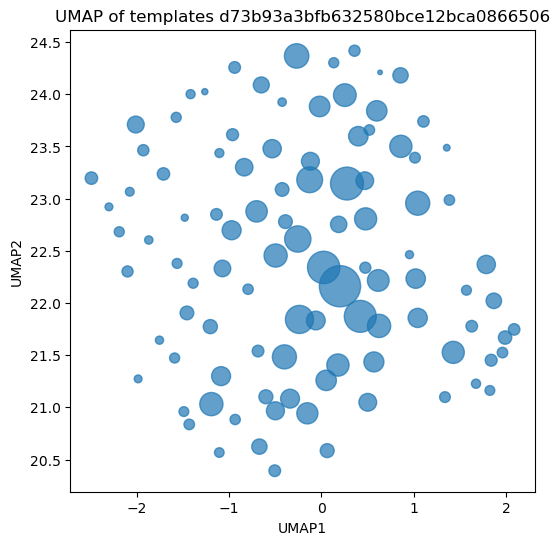

In [6]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Filter your dataframe
filtered = df_simplified[df_simplified["sample"] == "e441182799ba6725d4ae80e218ce3116"]

# Extract embeddings (make sure they are lists/arrays)
embeddings = np.array(filtered["cluster_embedding"].tolist())

# Initialize UMAP
reducer = umap.UMAP(n_neighbors=12, min_dist=0.1, random_state=42)

# Fit and transform
umap_embedding = reducer.fit_transform(embeddings)

# Optional: use a column for point size
# For example, using "counts" column or "size_metric"
sizes = filtered["templates"] if "templates" in filtered.columns else 10  # default size = 10

# Plot
plt.figure(figsize=(6,6))
plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    s=sizes,        # point sizes
    alpha=0.7
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of templates d73b93a3bfb632580bce12bca0866506")
plt.show()


In [7]:
from sklearn.neighbors import kneighbors_graph
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial.distance import cosine as cosine_distance


def build_knn_tcr_graph(cluster_embeddings, frequencies, k=10):
    num_clusters = len(cluster_embeddings)
    
    # Node features (with frequency)
    freq_normalized = (frequencies / frequencies.sum()).reshape(-1, 1)
    node_features = torch.cat([
        torch.tensor(cluster_embeddings, dtype=torch.float),
        torch.tensor(freq_normalized, dtype=torch.float)
    ], dim=1)
    
    # Create KNN graph
    knn = kneighbors_graph(cluster_embeddings, k, mode='connectivity', 
                          include_self=False, metric='cosine')
    
    # Convert to edge_index format
    edges = []
    edge_weights = []
    
    for i in range(num_clusters):
        neighbors = knn[i].nonzero()[1]
        for j in neighbors:
            edges.append([i, j])
            # Calculate similarity for edge weight
            sim = 1 - cosine_distance(cluster_embeddings[i], cluster_embeddings[j])
            edge_weights.append(sim)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

In [8]:
# build all graphs for each sample in df


def build_graphs_for_samples(df, k=10):
    graphs = {}
    for sample_id, group in df.groupby("sample"):
        cluster_embeddings = np.array(group["cluster_embedding"].tolist())
        frequencies = group["templates"].values
        graph = build_knn_tcr_graph(cluster_embeddings, frequencies, k)
        # graph label either 0 or 1 based on bool in label_positive column
        graph.y = torch.tensor([1 if group["label_positive"].iloc[0] else 0], dtype=torch.long)
        graphs[sample_id] = graph
    return graphs

In [9]:
filtered = df_simplified[df_simplified["sample"] == "e441182799ba6725d4ae80e218ce3116"]
embeddings = np.array(filtered["cluster_embedding"].tolist())
embeddings

frequencies = np.array(filtered["templates"].tolist())
frequencies

build_knn_tcr_graph(embeddings, frequencies)

Data(x=[100, 769], edge_index=[2, 1000], edge_attr=[1000, 1])

In [38]:
graphs_dict = build_graphs_for_samples(df_simplified, k=20)
dataset = list(graphs_dict.values())

In [39]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=33,
    stratify=[data.y.item() for data in dataset]  # keeps class balance
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)



In [79]:
from torch_geometric.loader import DataLoader

batch_size = 50

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

in_dim = dataset[0].x.shape[1]  # embedding_dim + 1 frequency feature
hidden_dim = 16
num_classes = 1


In [107]:
import tcrGNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = tcrGNN.TCRgnn(in_dim, hidden_dim, num_classes).to(device)
model = tcrGNN.TCRgnnEdge(in_dim, hidden_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


train_labels = torch.tensor([data.y.item() for data in train_data])

# compute number of positive and negative samples
num_pos = (train_labels == 1).sum().item()
num_neg = (train_labels == 0).sum().item()

# pos_weight = (# negative samples) / (# positive samples)
pos_weight = torch.tensor(num_neg / num_pos).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# criterion = torch.nn.BCEWithLogitsLoss()



In [85]:
import torch

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)          # shape: (batch_size, 1)
        out = out.view(-1)          # flatten to (batch_size,)
        y = batch.y.view(-1).float()  # ensure float for BCE
        
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)  # flatten
            y = batch.y.view(-1).float()
            
            pred = (torch.sigmoid(out) > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y = batch.y.view(-1).float()
            
            loss = criterion(out, y)
            total_loss += loss.item()
    
    return total_loss / len(loader)



In [68]:
from sklearn.metrics import roc_auc_score
import torch

def evaluate_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            
            probs = torch.sigmoid(out)  # convert logits to probability
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc, all_labels, all_probs


Epoch 001 | Train Loss: 0.8430 | Train Acc: 0.6736 | Val Loss: 0.9362 | Val Acc: 0.6099 | Val AUC: 0.5883 | Precision: 0.4203 | Recall: 0.4833
Epoch 002 | Train Loss: 0.8563 | Train Acc: 0.6460 | Val Loss: 0.9156 | Val Acc: 0.5549 | Val AUC: 0.5825 | Precision: 0.3846 | Recall: 0.5833
Epoch 003 | Train Loss: 0.8261 | Train Acc: 0.6928 | Val Loss: 0.9721 | Val Acc: 0.5989 | Val AUC: 0.5835 | Precision: 0.4000 | Recall: 0.4333
Epoch 004 | Train Loss: 0.8663 | Train Acc: 0.7273 | Val Loss: 0.9415 | Val Acc: 0.6099 | Val AUC: 0.5795 | Precision: 0.3878 | Recall: 0.3167
Epoch 005 | Train Loss: 0.8288 | Train Acc: 0.6598 | Val Loss: 0.9576 | Val Acc: 0.5824 | Val AUC: 0.5836 | Precision: 0.4024 | Recall: 0.5500


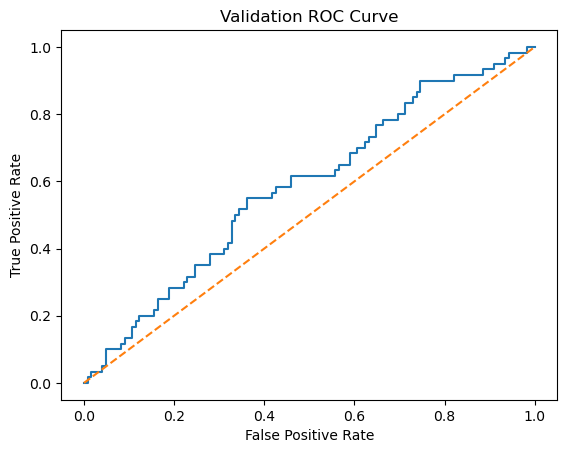

Confusion Matrix:
[[73 49]
 [27 33]]
Epoch 006 | Train Loss: 0.8310 | Train Acc: 0.6446 | Val Loss: 0.9364 | Val Acc: 0.5330 | Val AUC: 0.5775 | Precision: 0.3737 | Recall: 0.6167
Epoch 007 | Train Loss: 0.8148 | Train Acc: 0.7424 | Val Loss: 1.0158 | Val Acc: 0.6264 | Val AUC: 0.5791 | Precision: 0.4130 | Recall: 0.3167
Epoch 008 | Train Loss: 0.8279 | Train Acc: 0.7397 | Val Loss: 1.0385 | Val Acc: 0.6264 | Val AUC: 0.5765 | Precision: 0.3889 | Recall: 0.2333
Epoch 009 | Train Loss: 0.8377 | Train Acc: 0.7300 | Val Loss: 0.9459 | Val Acc: 0.6154 | Val AUC: 0.5734 | Precision: 0.4194 | Recall: 0.4333
Epoch 010 | Train Loss: 0.8284 | Train Acc: 0.7328 | Val Loss: 0.9816 | Val Acc: 0.6319 | Val AUC: 0.5708 | Precision: 0.3939 | Recall: 0.2167


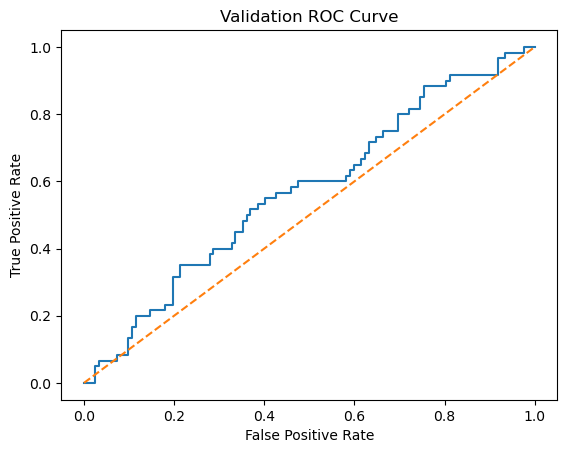

Confusion Matrix:
[[102  20]
 [ 47  13]]
Epoch 011 | Train Loss: 0.8034 | Train Acc: 0.7562 | Val Loss: 1.0197 | Val Acc: 0.6319 | Val AUC: 0.5630 | Precision: 0.4286 | Recall: 0.3500
Epoch 012 | Train Loss: 0.8036 | Train Acc: 0.7548 | Val Loss: 1.0481 | Val Acc: 0.6319 | Val AUC: 0.5658 | Precision: 0.3939 | Recall: 0.2167
Epoch 013 | Train Loss: 0.7951 | Train Acc: 0.6791 | Val Loss: 1.0013 | Val Acc: 0.4945 | Val AUC: 0.5362 | Precision: 0.3462 | Recall: 0.6000
Epoch 014 | Train Loss: 0.7985 | Train Acc: 0.6694 | Val Loss: 1.0245 | Val Acc: 0.5055 | Val AUC: 0.5184 | Precision: 0.3558 | Recall: 0.6167
Epoch 015 | Train Loss: 0.7550 | Train Acc: 0.7121 | Val Loss: 1.0569 | Val Acc: 0.5769 | Val AUC: 0.5555 | Precision: 0.3867 | Recall: 0.4833


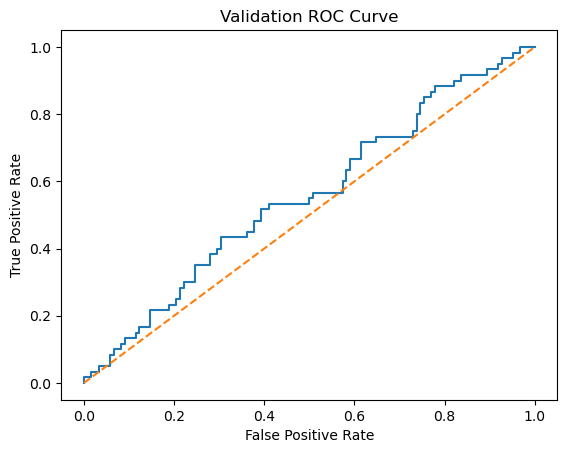

Confusion Matrix:
[[76 46]
 [31 29]]
Epoch 016 | Train Loss: 0.7452 | Train Acc: 0.7782 | Val Loss: 1.0852 | Val Acc: 0.5989 | Val AUC: 0.5477 | Precision: 0.3860 | Recall: 0.3667
Epoch 017 | Train Loss: 0.7190 | Train Acc: 0.6997 | Val Loss: 1.1393 | Val Acc: 0.5000 | Val AUC: 0.5306 | Precision: 0.3434 | Recall: 0.5667
Epoch 018 | Train Loss: 0.7187 | Train Acc: 0.7796 | Val Loss: 1.1569 | Val Acc: 0.5824 | Val AUC: 0.5286 | Precision: 0.3788 | Recall: 0.4167
Epoch 019 | Train Loss: 0.6978 | Train Acc: 0.5441 | Val Loss: 1.1973 | Val Acc: 0.4066 | Val AUC: 0.4982 | Precision: 0.3286 | Recall: 0.7667
Epoch 020 | Train Loss: 0.6972 | Train Acc: 0.8085 | Val Loss: 1.1595 | Val Acc: 0.5440 | Val AUC: 0.4922 | Precision: 0.3380 | Recall: 0.4000


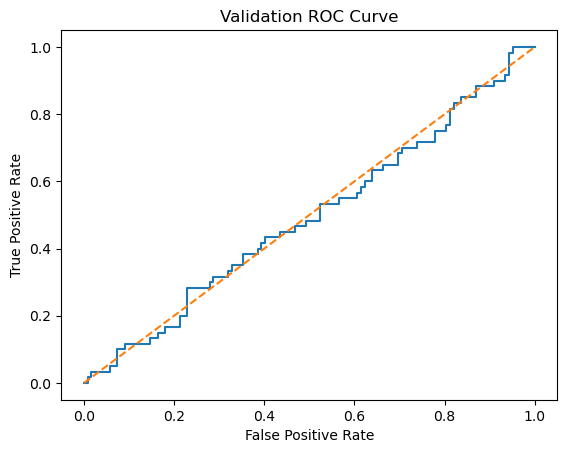

Confusion Matrix:
[[75 47]
 [36 24]]
Epoch 021 | Train Loss: 0.6786 | Train Acc: 0.7562 | Val Loss: 1.1466 | Val Acc: 0.4835 | Val AUC: 0.4675 | Precision: 0.3152 | Recall: 0.4833
Epoch 022 | Train Loss: 0.6658 | Train Acc: 0.7865 | Val Loss: 1.1744 | Val Acc: 0.5275 | Val AUC: 0.4760 | Precision: 0.3143 | Recall: 0.3667
Epoch 023 | Train Loss: 0.6100 | Train Acc: 0.7824 | Val Loss: 1.3469 | Val Acc: 0.5000 | Val AUC: 0.4831 | Precision: 0.3368 | Recall: 0.5333
Epoch 024 | Train Loss: 0.6159 | Train Acc: 0.8444 | Val Loss: 1.3272 | Val Acc: 0.5604 | Val AUC: 0.5111 | Precision: 0.3649 | Recall: 0.4500
Epoch 025 | Train Loss: 0.5938 | Train Acc: 0.8306 | Val Loss: 1.3812 | Val Acc: 0.5110 | Val AUC: 0.5003 | Precision: 0.3407 | Recall: 0.5167


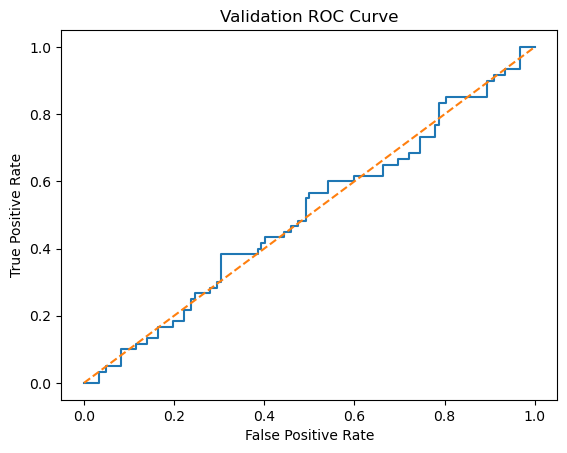

Confusion Matrix:
[[62 60]
 [29 31]]
Epoch 026 | Train Loss: 0.5204 | Train Acc: 0.8636 | Val Loss: 1.6647 | Val Acc: 0.5110 | Val AUC: 0.4914 | Precision: 0.3294 | Recall: 0.4667
Epoch 027 | Train Loss: 0.5251 | Train Acc: 0.8650 | Val Loss: 1.3442 | Val Acc: 0.5330 | Val AUC: 0.4930 | Precision: 0.3333 | Recall: 0.4167
Epoch 028 | Train Loss: 0.5111 | Train Acc: 0.8705 | Val Loss: 1.4979 | Val Acc: 0.4725 | Val AUC: 0.4802 | Precision: 0.3085 | Recall: 0.4833
Epoch 029 | Train Loss: 0.4195 | Train Acc: 0.9174 | Val Loss: 1.8672 | Val Acc: 0.5440 | Val AUC: 0.4908 | Precision: 0.3231 | Recall: 0.3500
Epoch 030 | Train Loss: 0.4317 | Train Acc: 0.9132 | Val Loss: 1.9612 | Val Acc: 0.5824 | Val AUC: 0.5101 | Precision: 0.3667 | Recall: 0.3667


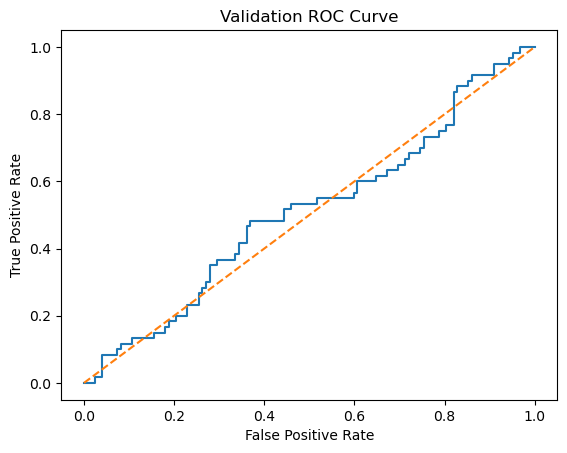

Confusion Matrix:
[[84 38]
 [38 22]]
Epoch 031 | Train Loss: 0.4120 | Train Acc: 0.9091 | Val Loss: 1.9262 | Val Acc: 0.5330 | Val AUC: 0.4918 | Precision: 0.3457 | Recall: 0.4667
Epoch 032 | Train Loss: 0.4820 | Train Acc: 0.8306 | Val Loss: 1.5994 | Val Acc: 0.4945 | Val AUC: 0.4650 | Precision: 0.2895 | Recall: 0.3667
Epoch 033 | Train Loss: 0.4063 | Train Acc: 0.9229 | Val Loss: 2.0174 | Val Acc: 0.5330 | Val AUC: 0.4984 | Precision: 0.3239 | Recall: 0.3833
Epoch 034 | Train Loss: 0.3293 | Train Acc: 0.8636 | Val Loss: 3.2495 | Val Acc: 0.6154 | Val AUC: 0.5148 | Precision: 0.3333 | Recall: 0.1667
Epoch 035 | Train Loss: 0.3529 | Train Acc: 0.9601 | Val Loss: 2.1708 | Val Acc: 0.5824 | Val AUC: 0.5137 | Precision: 0.3667 | Recall: 0.3667


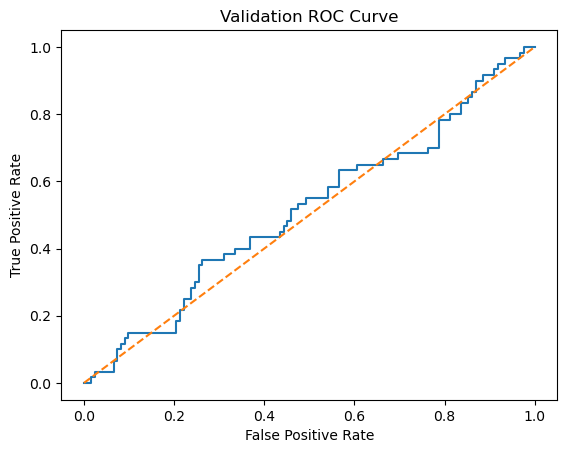

Confusion Matrix:
[[84 38]
 [38 22]]
Epoch 036 | Train Loss: 0.3101 | Train Acc: 0.8788 | Val Loss: 2.5368 | Val Acc: 0.4945 | Val AUC: 0.4872 | Precision: 0.3222 | Recall: 0.4833
Epoch 037 | Train Loss: 0.4457 | Train Acc: 0.9270 | Val Loss: 1.9729 | Val Acc: 0.5495 | Val AUC: 0.5045 | Precision: 0.3429 | Recall: 0.4000
Epoch 038 | Train Loss: 0.2672 | Train Acc: 0.9532 | Val Loss: 2.4745 | Val Acc: 0.5769 | Val AUC: 0.5053 | Precision: 0.3803 | Recall: 0.4500
Epoch 039 | Train Loss: 0.2220 | Train Acc: 0.9449 | Val Loss: 3.5043 | Val Acc: 0.5989 | Val AUC: 0.5290 | Precision: 0.3243 | Recall: 0.2000
Epoch 040 | Train Loss: 0.2488 | Train Acc: 0.9642 | Val Loss: 3.3701 | Val Acc: 0.5769 | Val AUC: 0.5077 | Precision: 0.3509 | Recall: 0.3333


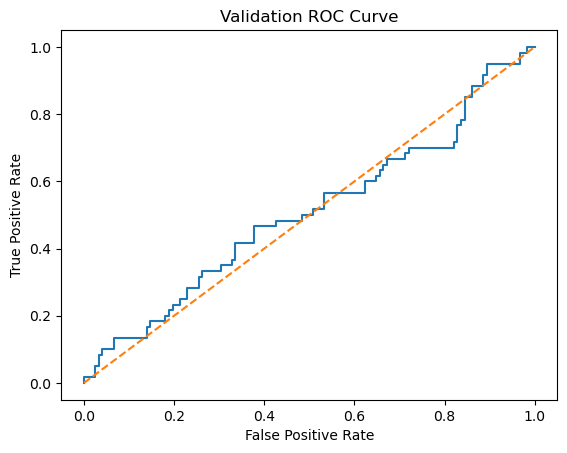

Confusion Matrix:
[[85 37]
 [40 20]]
Epoch 041 | Train Loss: 0.2628 | Train Acc: 0.9063 | Val Loss: 2.4100 | Val Acc: 0.5330 | Val AUC: 0.4883 | Precision: 0.3563 | Recall: 0.5167
Epoch 042 | Train Loss: 0.1739 | Train Acc: 0.9559 | Val Loss: 2.6874 | Val Acc: 0.5110 | Val AUC: 0.5012 | Precision: 0.3333 | Recall: 0.4833
Epoch 043 | Train Loss: 0.1872 | Train Acc: 0.9174 | Val Loss: 3.3720 | Val Acc: 0.5220 | Val AUC: 0.4883 | Precision: 0.3483 | Recall: 0.5167
Epoch 044 | Train Loss: 0.2562 | Train Acc: 0.8733 | Val Loss: 2.8736 | Val Acc: 0.4780 | Val AUC: 0.4936 | Precision: 0.3364 | Recall: 0.6000
Epoch 045 | Train Loss: 0.1644 | Train Acc: 0.9298 | Val Loss: 3.4035 | Val Acc: 0.5220 | Val AUC: 0.4921 | Precision: 0.3548 | Recall: 0.5500


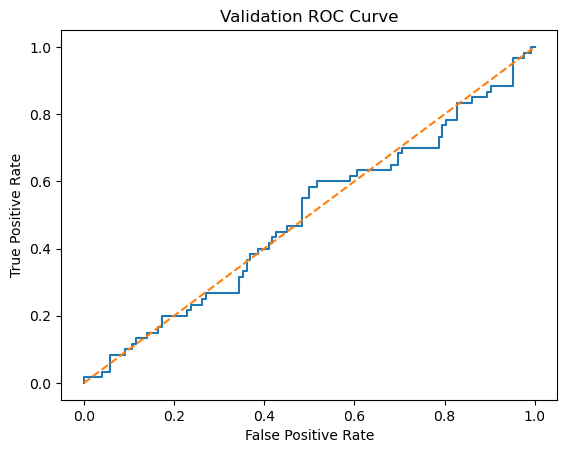

Confusion Matrix:
[[62 60]
 [27 33]]
Epoch 046 | Train Loss: 0.1637 | Train Acc: 0.9876 | Val Loss: 3.6522 | Val Acc: 0.5934 | Val AUC: 0.5127 | Precision: 0.3704 | Recall: 0.3333
Epoch 047 | Train Loss: 0.1373 | Train Acc: 0.9917 | Val Loss: 3.8462 | Val Acc: 0.5714 | Val AUC: 0.5133 | Precision: 0.3636 | Recall: 0.4000
Epoch 048 | Train Loss: 0.1492 | Train Acc: 0.9904 | Val Loss: 3.7841 | Val Acc: 0.5824 | Val AUC: 0.5141 | Precision: 0.3857 | Recall: 0.4500
Epoch 049 | Train Loss: 0.1739 | Train Acc: 0.9848 | Val Loss: 3.9640 | Val Acc: 0.5769 | Val AUC: 0.5067 | Precision: 0.3731 | Recall: 0.4167
Epoch 050 | Train Loss: 0.1861 | Train Acc: 0.9780 | Val Loss: 4.0460 | Val Acc: 0.5824 | Val AUC: 0.5143 | Precision: 0.3621 | Recall: 0.3500


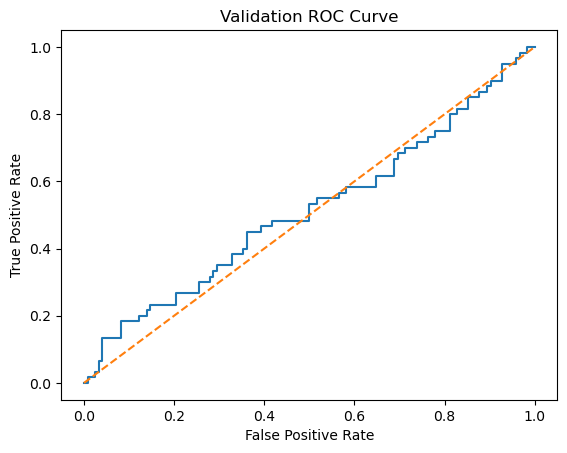

Confusion Matrix:
[[85 37]
 [39 21]]


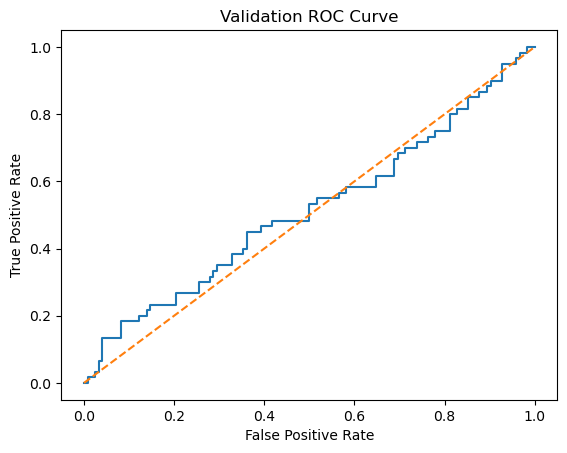

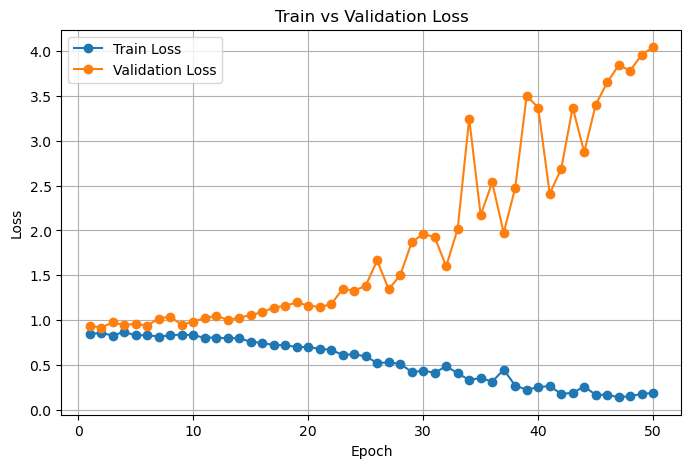

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix

num_epochs = 50

# store losses for plotting
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)
    
    precision = precision_score(labels, preds)
    recall    = recall_score(labels, preds)
    cm        = confusion_matrix(labels, preds)
    
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )
    
    if (epoch+1) % 5 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)

# Final ROC plot
plot_roc(labels, probs)

# --- Plot train and val loss ---
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [38]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
print("Class counts:", class_counts)

num_classes = len(class_counts)
total_samples = len(labels)

class_weights = total_samples / (num_classes * class_counts.float())
print("Class weights:", class_weights)


criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)


Class counts: tensor([610, 298])
Class weights: tensor([0.7443, 1.5235])


In [39]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
total_samples = len(labels)

majority_class_count = class_counts.max().item()

baseline_accuracy = majority_class_count / total_samples

print("Class counts:", class_counts.tolist())
print("Baseline accuracy:", baseline_accuracy)


Class counts: [610, 298]
Baseline accuracy: 0.6718061674008811
